# Looking at particle loss

Peneration: 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\losses'
filename = 'NYA_Losses_CVI_20190222.xlsx'
df = pd.read_excel(loadpath+'\\'+str(filename), skiprows=1)
print(df.columns)
plt.rcParams["font.family"] = 'monospace'

Index(['LossPerc', 'D', 'LossPerc.1', 'D.1', 'LossPerc.2', 'D.2', 'LossPerc.3',
       'Unnamed: 7'],
      dtype='str')


In [2]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [3]:
df.columns = ['LossPerc_TinTin', 'Dp_TinTin', 'LossPerc_NestorClear', 'Dp_NestorClear', 'LossPerc_NestorBeforeswitch', 'Dp_NestorBeforeswitch', 'LossPerc_NestorCloudy', 'Dp_NestorCloudy']

In [4]:
df_wholeair_loss = pd.read_csv(
    loadpath + '\\' + 'loss_wholeair.txt',
    sep=r'\t+',
    engine='python'
)

In [5]:
df_wholeair_loss.head(2)

,dp,Loss
0,0.0050,36.523457
1,0.0051,35.810806


In [6]:
def loss_curve(df_wholeair_loss):
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    ax.plot(df_wholeair_loss['dp'].values, df_wholeair_loss['Loss'].values, 'o-', ms=2, lw=2, label='5 tubing parameters', c='k')
    ax.set_ylabel('Particle Loss [%]')
    ax.set_xlabel('Particle Diameter [nm]')
    ax.legend(frameon=False)
    ax.set_xscale('log')
    ax.set_xticks([0.005, 0.05, 0.8500], [5, 50, 850])
    plt.show()
    return fig

In [7]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

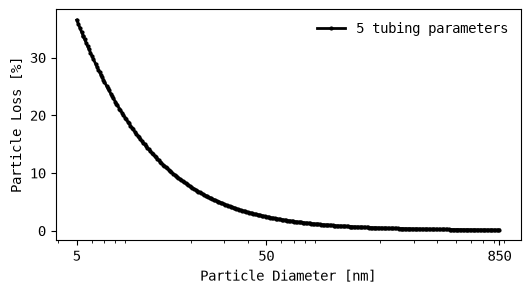

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_S1.jpeg


In [8]:
fig = loss_curve(df_wholeair_loss)
output_figure = plots_outpath / 'Figure_S1.jpeg'
save_plot(fig, output_figure)